In [64]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [51]:
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")

## Sequential Workflow

In [52]:
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:
    '''This node gives the outline for writing a blog on the input topic'''

    topic = state["topic"]
    
    prompt = f'Generate a detailed outline for a blog on the topic - {topic}'
    outline = model.invoke(prompt).content
    state['outline'] = outline

    return state


def create_blog(state: BlogState) -> BlogState:
    '''This node writes the content of a blog given the topic and outline.'''

    topic = state["topic"]
    outline = state['outline']

    prompt = f'Write a detailed blog on the topic - {topic} using the following outline: \n {outline}'
    content = model.invoke(prompt).content
    state['content'] = content

    return state

In [14]:
graph = StateGraph(BlogState)

#nodes
graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)

workflow = graph.compile()


In [16]:
initial_state = {'topic':'The Wheel of Life'}
final_state = workflow.invoke(initial_state)
final_state

{'topic': 'The Wheel of Life',
 'outline': '**Title:** "Finding Balance in the Wheel of Life: A Comprehensive Guide to Achieving Happiness and Fulfillment"\n\n**I. Introduction**\n\n* Brief overview of the concept of the Wheel of Life\n* Importance of maintaining balance and harmony in life\n* Thesis statement: By understanding and mastering the various aspects of the Wheel of Life, individuals can achieve a state of balance and fulfillment, leading to a more purposeful and happy life.\n\n**II. Background and History of the Wheel of Life**\n\n* Origins of the concept\n* Evolution of the Wheel of Life in various cultures and traditions\n* Key principles and philosophies underlying the concept\n\n**III. Understanding the Different Sectors of the Wheel of Life**\n\n* **Physical Health (Physical Sector)**\n\t+ Importance of physical well-being\n\t+ Factors affecting physical health (nutrition, exercise, sleep, etc.)\n\t+ Strategies for maintaining physical health\n* **Career and Finances (

## Parallel Workflow

In [53]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay")
    score: int = Field(description="Evaluation score for the essay out of 10", ge=0, le=10)

In [54]:
structured_model = model.with_structured_output(EvaluationSchema)

In [55]:
class UPSC_State(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str 
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add] #Reducer function
    avg_score: float

In [56]:
def evaluate_language(state: UPSC_State):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [57]:
def evaluate_analysis(state: UPSC_State):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [58]:
def evaluate_thought(state: UPSC_State):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [59]:
def final_evaluation(state: UPSC_State):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
    

In [60]:
graph = StateGraph(UPSC_State)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

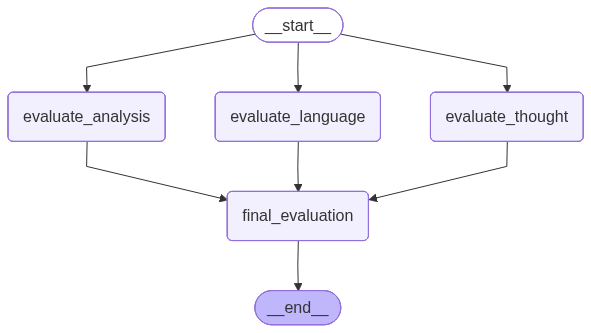

In [61]:
workflow

In [62]:
essay = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

In [63]:
intial_state = {
    'essay': essay
}

workflow.invoke(intial_state)

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

## Iterative + Conditional Workflow

In [104]:
generator_llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)
evaluator_llm = ChatGroq(model="llama-3.3-70b-versatile")
optimizer_llm = ChatGroq(model="llama-3.1-8b-instant")

In [94]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [95]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [96]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved','needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [97]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}    

In [98]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}    


In [99]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [100]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] > state['max_iteration']:
        return "approved"
    else:
        return "needs_improvement"

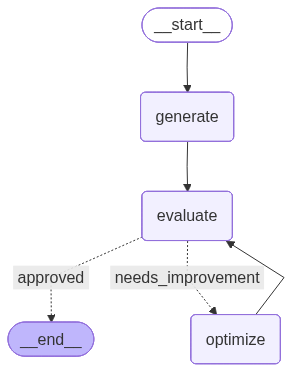

In [101]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [123]:
initial_state = {
    "topic": "Egdbeq",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [124]:
result

{'topic': 'Egdbeq',
 'tweet': '"Just tried to Google \'Egdbeq\' and all I got was a bunch of confused Google Translate results. Guess that\'s what happens when you try to find answers to life\'s mysteries online... or a made-up word #Egdbeq #GoogleFail"',
 'evaluation': 'approved',
 'feedback': "This tweet is a breath of fresh air, showcasing originality by using a made-up word to poke fun at the limitations of online searches. The humor is subtle yet effective, and the punchiness is spot on, making it scroll-stopping. The tweet's virality potential is high, as people can relate to the frustration of not finding what they're looking for online. The format is well-executed, with a clever use of hashtags and a concise message that stays within the 280-character limit. Overall, this tweet effectively balances creativity, humor, and relatability, making it a compelling and engaging post.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Just tried to Google \'Egdbeq\' and all I 